# 1.2 数据的分布

## 1.2.1 直方图、经验分布函数与QQ图

### 1.直方图

**直方图**(Histogram)，又称**质量分布图**，是一种统计报告图，由一系列高度不等的纵向条纹或线段表示数据分布的情况。 一般用横轴表示数据类型，纵轴表示分布情况（频率）。
    
画直方图的步骤：  
（1）**收集数据。**抽取的样本数量过小，将会产生较大误差，可信度低，也就失去了统计的意义。因此，样本数不应少于50个。      
（2）**确定数据的极差(R)。**用数据的最大值减去最小值求得。    
（3）**确定组距(h)。**先确定直方图的组数，然后以此组数去除极差，可得直方图每组的宽度，即组距。  
（4）**确定各组的界限值。**为避免出现数据值与组界限值重合而造成频率计算困难，组的界限值单位应取最小测量单位的1/2。

直方图的应用场景：  
（1）直方图用于概率分布，展示一组数据在指定范围内的出现概率。  
（2）可以用于展示数据分布频率情况。  
（3）用于确认众数、中位数的位置。  
（4）关注数据存在缺口或者异常值。   

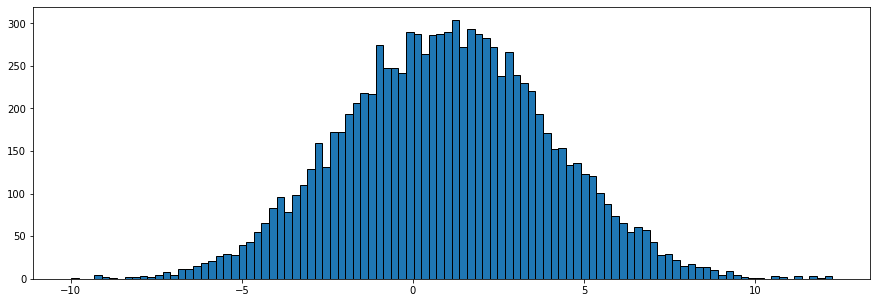

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

x_value = np.random.normal(loc=1.0, scale=3.0, size=10000)
plt.figure(figsize=(15,5))
plt.hist(x_value,bins=100,edgecolor='k')
plt.show()

### 2.经验分布函数   

**经验分布函数**(cumulative distribution function)亦称**累积分布函数**，统计学中的基本概念之一。经验分布函数Fn(x)具有分布函数的性质，我们可以将其看成是以等概率1/n 取值X<sub>1</sub>，X<sub>2</sub>，...，X<sub>n</sub>的离散型随机变量的分布函数。且该函数的图形呈跳跃式一条台阶形折线，如观测值不重复，则每一跳跃为1/n ，如有重复，则按1/n的倍数跳跃上升。  

设(X<sub>1</sub>，X<sub>2</sub>，…，X<sub>n</sub>)是来自总体X的一个简单随机样本，将其一个观测值(x<sub>1</sub>，x<sub>2</sub>，…x<sub>n</sub>)按从小到大的顺序排列成
$$x_{(1)}<x_{(2)}<...<x_{(n)}$$  
其中$x_{(i)}(i=1,2,...,r)$出现的频数为$n_i(n_1+n_2+...+n_r=n)$,记
$$F_n(x)=\begin{cases}0,&x<x_{(1)}\\\frac{n_1+n_2+...+n_k}{n},&x_{(k)}\leq x<x_{(k+1)};(k=1,2,...,r-1)\\1,&x\geq x_{(r)}\end{cases}$$  
称F(X)为总体X的经验分布函数。  

**图像意义**  
经验分布函数的图像是一条跳跃式上升的阶梯形曲线，在每个间断点x<sub>(k)</sub>处跳跃。若样本观测值的各分量x<sub>1</sub>，x<sub>2</sub>，…x<sub>n</sub>不重复，则每一跃度为$\frac{1}{n}$；若某一分量重复m次，则在该分量处跃度为$\frac{m}{n}$。


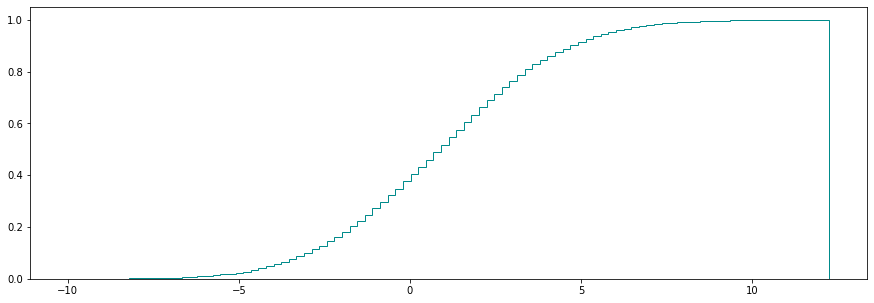

In [7]:
plt.figure(figsize=(15,5))
plt.hist(x_value, bins=100, histtype='step',cumulative=True, density=True, color='darkcyan')
plt.show()

### 3.QQ图  

全称**quantile-quantile plot**，中文名**分位数-分位数图**，用图形的方式比较两组数据的经验分布函数来判断两组数据是否是服从同一分布。  

**分位数（quantile）**的概念与累计分布函数类似，也是一种概率累计过程，如第一四分位数是累积分布概率达到0.25时所对应的变量值，第二四分位数是累计分布概率达到0.5时对应的值，第三四分位数是累计分布概率达到0.75时对应的值，公式如下：  
α代表累计概率，分位数为Zα：$$P(X\leq Zα) = α$$  



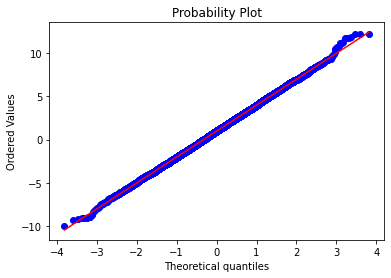

In [8]:
from scipy import stats
stats.probplot(x_value, dist="norm", plot=plt)
plt.show()

In [4]:
help(stats.probplot)

Help on function probplot in module scipy.stats._morestats:

probplot(x, sparams=(), dist='norm', fit=True, plot=None, rvalue=False)
    Calculate quantiles for a probability plot, and optionally show the plot.
    
    Generates a probability plot of sample data against the quantiles of a
    specified theoretical distribution (the normal distribution by default).
    `probplot` optionally calculates a best-fit line for the data and plots the
    results using Matplotlib or a given plot function.
    
    Parameters
    ----------
    x : array_like
        Sample/response data from which `probplot` creates the plot.
    sparams : tuple, optional
        Distribution-specific shape parameters (shape parameters plus location
        and scale).
    dist : str or stats.distributions instance, optional
        Distribution or distribution function name. The default is 'norm' for a
        normal probability plot.  Objects that look enough like a
        stats.distributions instance (i.e.